<a href="https://colab.research.google.com/github/alvitonikanor6-byte/AmazonReviews/blob/main/Amazon_Reviews.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

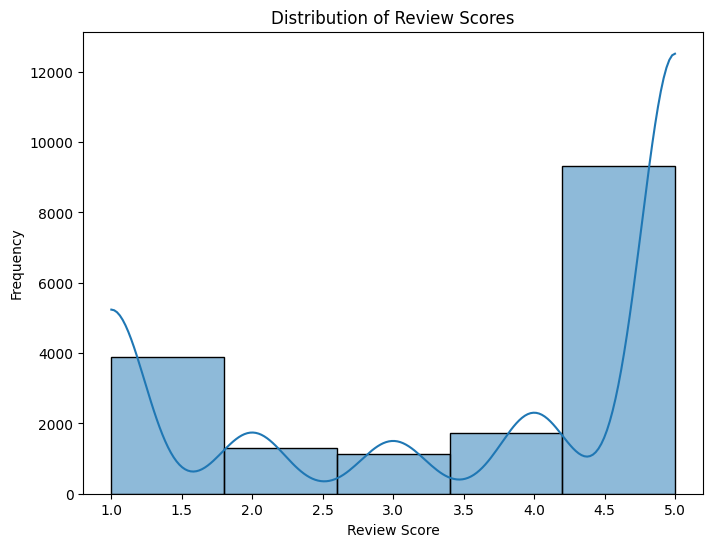

In [16]:
plt.figure(figsize=(8, 6))
sns.histplot(df['review_score'], bins=5, kde=True)
plt.title('Distribution of Review Scores')
plt.xlabel('Review Score')
plt.ylabel('Frequency')
plt.xticks(df['review_score'].unique().sort())
plt.show()

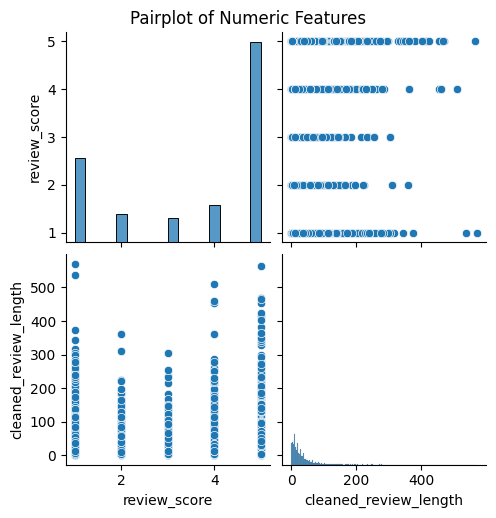

In [17]:
# Menghitung panjang ulasan jika kolom belum ada
if 'cleaned_review_length' not in df.columns:
    df['cleaned_review_length'] = df['cleaned_review'].fillna('').apply(len)

numeric_cols = ['review_score', 'cleaned_review_length']
sns.pairplot(df[numeric_cols])
plt.suptitle('Pairplot of Numeric Features', y=1.02)
plt.show()

In [15]:
from google.colab import files
uploaded = files.upload()

Saving Amazon_Reviews.csv to Amazon_Reviews.csv


In [20]:
df.info()
df.columns
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17340 non-null  object 
 1   cleaned_review         17337 non-null  object 
 2   cleaned_review_length  17340 non-null  int64  
 3   review_score           17340 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 542.0+ KB


,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer with a maximum of 5000 features
tfidf = TfidfVectorizer(max_features=5000)

# Fit and transform the training data, and transform the test data
# Fill NaN values in 'cleaned_review' with an empty string before vectorizing
X_train_tfidf = tfidf.fit_transform(X_train.fillna(''))
X_test_tfidf = tfidf.transform(X_test.fillna(''))

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

Shape of X_train_tfidf: (13872, 5000)
Shape of X_test_tfidf: (3468, 5000)


In [22]:
from sklearn.naive_bayes import MultinomialNB

# Initialize the Multinomial Naive Bayes classifier
naive_bayes_model = MultinomialNB()

# Train the model using the TF-IDF transformed training data and labels
naive_bayes_model.fit(X_train_tfidf, y_train)

print("Multinomial Naive Bayes model trained successfully.")

Multinomial Naive Bayes model trained successfully.


In [23]:
# Make predictions on the TF-IDF transformed test data
y_pred = naive_bayes_model.predict(X_test_tfidf)

print("Predictions made on the test set.")

Predictions made on the test set.


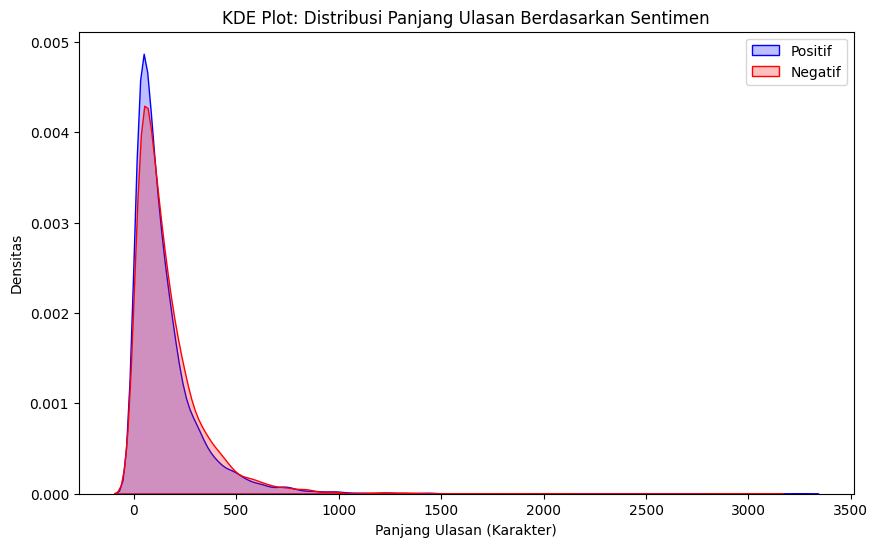

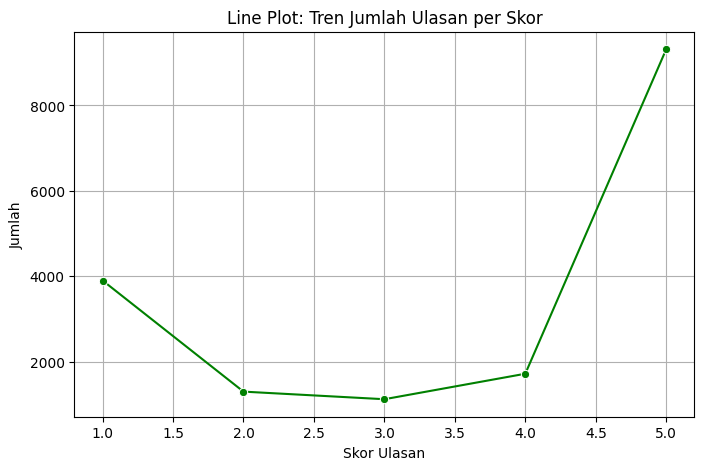

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Hitung kembali panjang ulasan karena kolom tersebut sebelumnya terhapus
df['cleaned_review_length'] = df['cleaned_review'].fillna('').apply(len)

# 1. KDE Plot (Kernel Density Estimate) untuk Panjang Ulasan
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[y==1]['cleaned_review_length'], label='Positif', fill=True, color='blue')
sns.kdeplot(data=df[y==0]['cleaned_review_length'], label='Negatif', fill=True, color='red')
plt.title('KDE Plot: Distribusi Panjang Ulasan Berdasarkan Sentimen')
plt.xlabel('Panjang Ulasan (Karakter)')
plt.ylabel('Densitas')
plt.legend()
plt.show()

# 2. Line Plot (Tren Jumlah Ulasan per Skor)
plt.figure(figsize=(8, 5))
score_counts = df.groupby('review_score').size()
sns.lineplot(x=score_counts.index, y=score_counts.values, marker='o', color='green')
plt.title('Line Plot: Tren Jumlah Ulasan per Skor')
plt.xlabel('Skor Ulasan')
plt.ylabel('Jumlah')
plt.grid(True)
plt.show()

Akurasi Model: 0.6277

Laporan Klasifikasi:
              precision    recall  f1-score   support

           0       0.47      0.16      0.24      1262
           1       0.65      0.89      0.75      2206

    accuracy                           0.63      3468
   macro avg       0.56      0.53      0.50      3468
weighted avg       0.58      0.63      0.57      3468



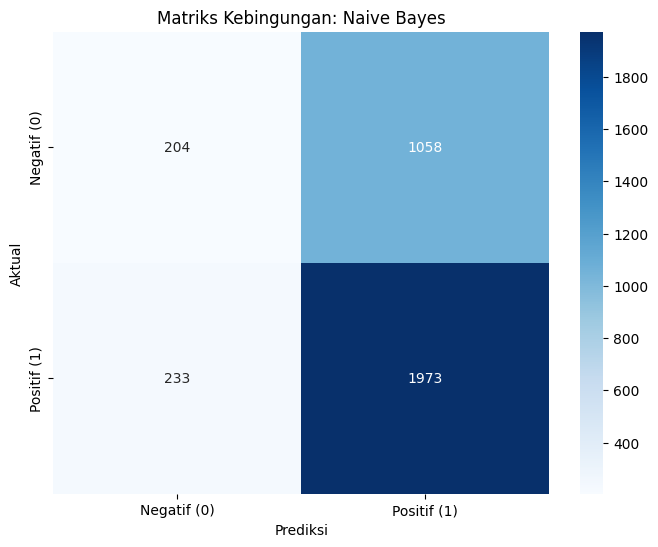

In [26]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Inisialisasi dan Latih Model
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

# 2. Prediksi
y_pred = nb_model.predict(X_test_tfidf)

# 3. Evaluasi
accuracy = accuracy_score(y_test, y_pred)
print(f'Akurasi Model: {accuracy:.4f}')
print('\nLaporan Klasifikasi:')
print(classification_report(y_test, y_pred))

# 4. Visualisasi Heatmap Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif (0)', 'Positif (1)'],
            yticklabels=['Negatif (0)', 'Positif (1)'])
plt.title('Matriks Kebingungan: Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

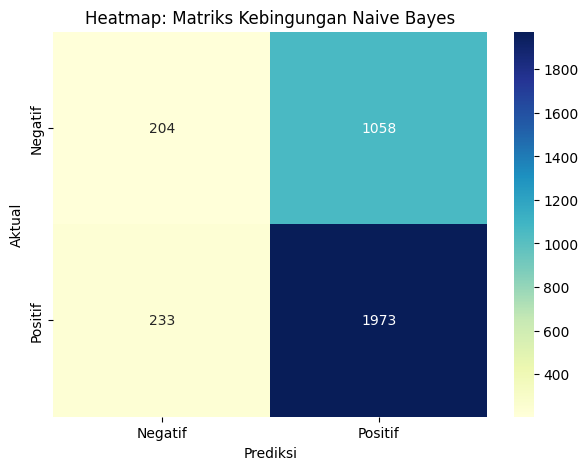

In [27]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import confusion_matrix, classification_report

# Memastikan model dilatih (jika belum)
nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train)
y_pred = nb.predict(X_test_tfidf)

# Heatmap Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Negatif', 'Positif'],
            yticklabels=['Negatif', 'Positif'])
plt.title('Heatmap: Matriks Kebingungan Naive Bayes')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

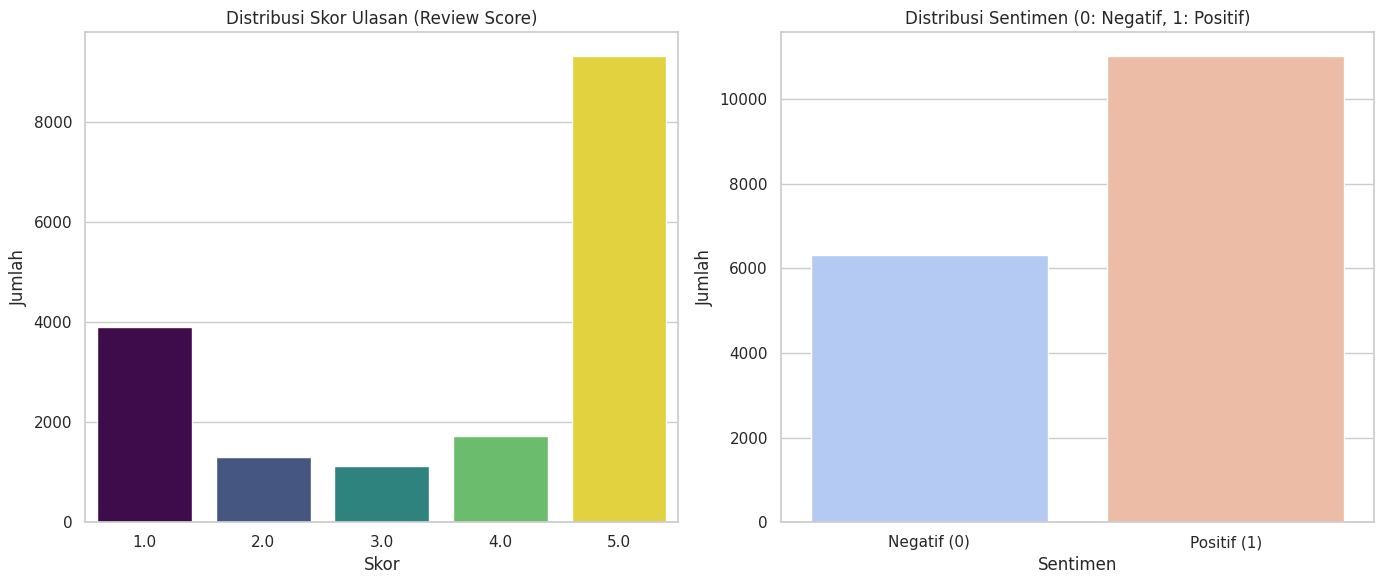

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set(style="whitegrid")

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Distribution of Review Scores
sns.countplot(data=df, x='review_score', ax=axes[0], palette='viridis', hue='review_score', legend=False)
axes[0].set_title('Distribusi Skor Ulasan (Review Score)')
axes[0].set_xlabel('Skor')
axes[0].set_ylabel('Jumlah')

# 2. Sentiment Class Distribution
sns.countplot(x=y, ax=axes[1], palette='coolwarm', hue=y, legend=False)
axes[1].set_title('Distribusi Sentimen (0: Negatif, 1: Positif)')
axes[1].set_xlabel('Sentimen')
axes[1].set_ylabel('Jumlah')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Negatif (0)', 'Positif (1)'])

plt.tight_layout()
plt.show()

Persentase Distribusi Sentimen:
review_score
1    63.61015
0    36.38985
Name: proportion, dtype: float64


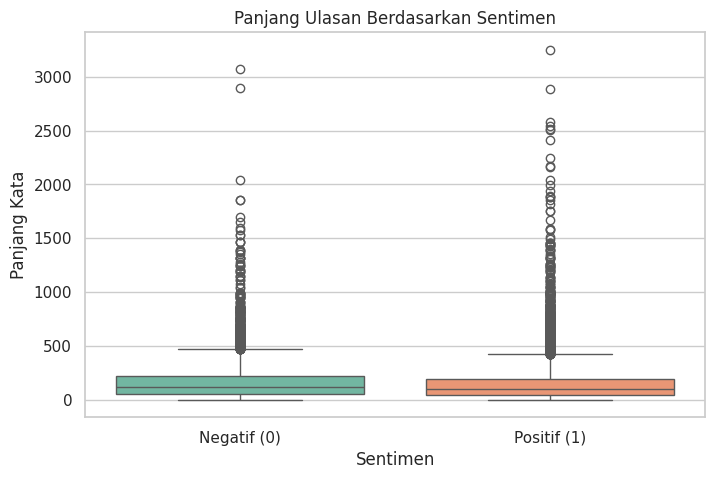

In [29]:
# Menghitung persentase tiap kelas
sentiment_counts = y.value_counts(normalize=True) * 100
print("Persentase Distribusi Sentimen:")
print(sentiment_counts)

# Visualisasi boxplot panjang ulasan terhadap sentimen jika kolom panjang tersedia
if 'cleaned_review_length' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x=y, y=df['cleaned_review_length'], palette='Set2', hue=y, legend=False)
    plt.title('Panjang Ulasan Berdasarkan Sentimen')
    plt.xlabel('Sentimen')
    plt.ylabel('Panjang Kata')
    plt.xticks([0, 1], ['Negatif (0)', 'Positif (1)'])
    plt.show()

Akurasi Model Naive Bayes: 0.6277

Laporan Klasifikasi:

              precision    recall  f1-score   support

           0       0.47      0.16      0.24      1262
           1       0.65      0.89      0.75      2206

    accuracy                           0.63      3468
   macro avg       0.56      0.53      0.50      3468
weighted avg       0.58      0.63      0.57      3468



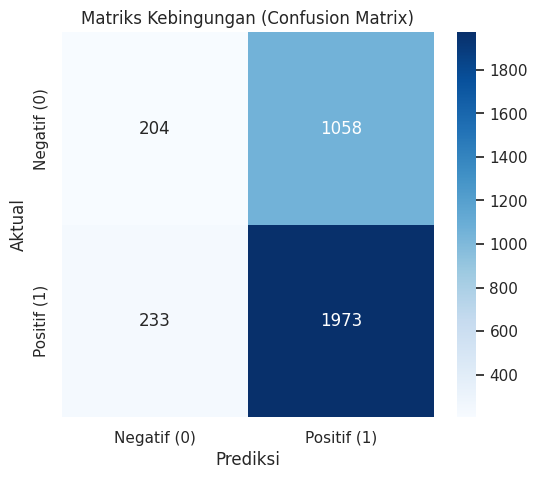

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Akurasi Model Naive Bayes: {accuracy:.4f}\n")

# Display classification report
print("Laporan Klasifikasi:\n")
print(classification_report(y_test, y_pred))

# Display confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negatif (0)', 'Positif (1)'],
            yticklabels=['Negatif (0)', 'Positif (1)'])
plt.title('Matriks Kebingungan (Confusion Matrix)')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()